# Problem 2 (Regression)

- Import needed libraries
- import csv file and split it into 3 datasets [training , validation , testing]

In [118]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("California_Houses.csv")




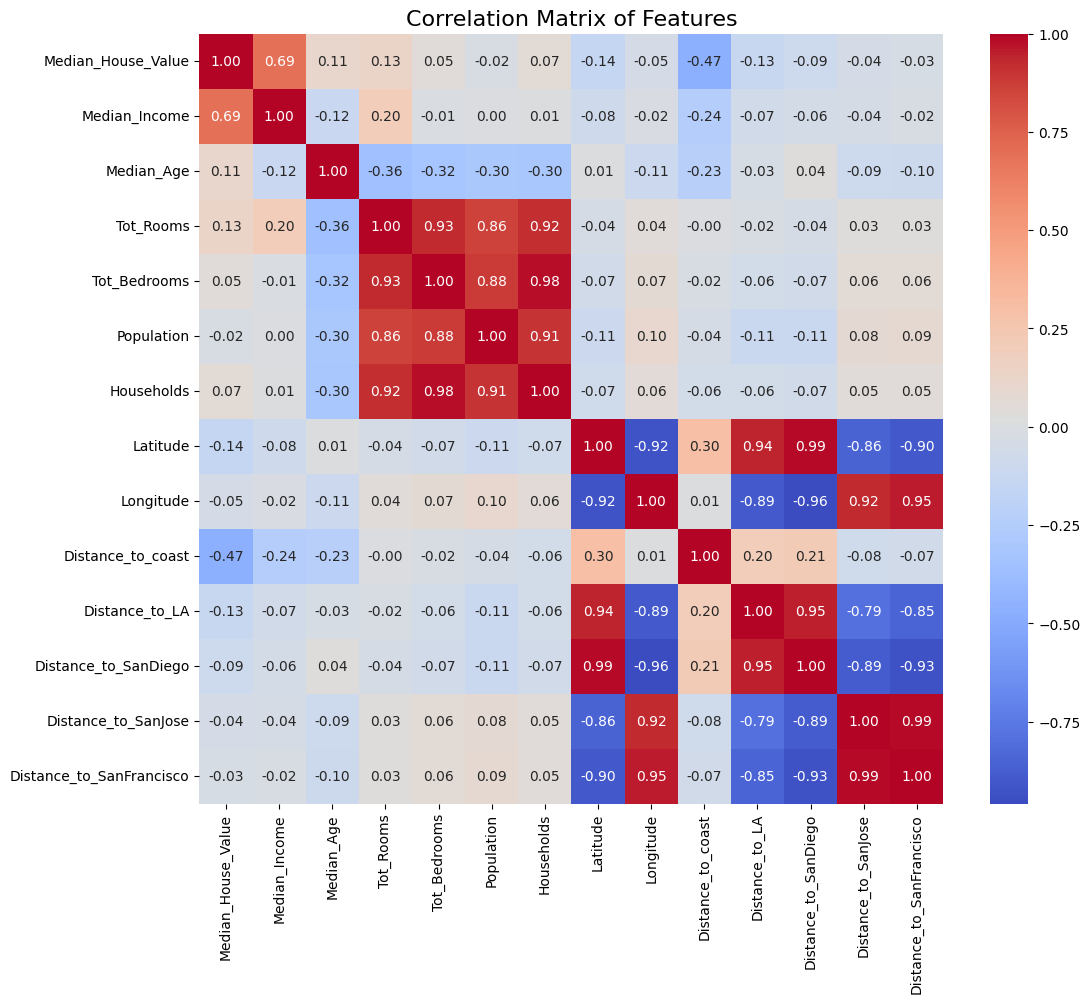

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Calculate the correlation matrix from your DataFrame ---
correlation_matrix = df.corr()

# --- 2. Create the heatmap ---
plt.figure(figsize=(12, 10)) # You can adjust the figure size as needed
sns.heatmap(
    correlation_matrix, 
    annot=True,         # Show the correlation values on the heatmap
    fmt='.2f',          # Format the numbers to two decimal places
    cmap='coolwarm'     # Use the 'coolwarm' color map
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

In [120]:

# Create a figure for plotting
# plt.figure(figsize=(14, 6))

# # Plot the original distribution of the target variable
# plt.subplot(1, 2, 1)
# sns.histplot(df['Median_House_Value'], kde=True)
# plt.title('Original Distribution of Median House Value')
# plt.xlabel('Median House Value')
# plt.ylabel('Frequency')

# Apply a log transform to the target variable
# We use np.log1p which calculates log(1 + x) to avoid issues with zero values
# df['Median_House_Value_Log'] = np.log1p(df['Median_House_Value'])

# # Plot the new distribution after log transform
# plt.subplot(1, 2, 2)
# sns.histplot(df['Median_House_Value_Log'], kde=True, color='green')
# plt.title('Distribution After Log Transform')
# plt.xlabeel('Log(1+Median House Value)')
# plt.ylabel('Frequency')




In [121]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

calculate mean squared error and mean absolute erro

In [122]:
def mean_squared(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)


def mean_absolute(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


Normalize datasets , X = ( X - mean ) / standard deviation

In [123]:
# --- Compute normalization parameters from the training set only ---
means = train_df.mean(numeric_only=True)   # mean of each numeric feature
stds = train_df.std(numeric_only=True)     # standard deviation of each numeric feature

# --- Apply Z-score normalization using training statistics ---
# (X_norm = (X - mean_train) / std_train)
train_norm = (train_df - means) / stds
val_norm = (val_df - means) / stds
test_norm = (test_df - means) / stds


Added Bias coloumn for datasets and dropped target coloumn

In [124]:
# --- Define the target column ---
target_col = "Median_House_Value"

# Separate features (X) and target (y) for each dataset
# Drop the target column to keep only feature values
X = train_norm.drop(columns=[target_col]).to_numpy()
V = val_norm.drop(columns=[target_col]).to_numpy()
Test = test_norm.drop(columns=[target_col]).to_numpy()

# --- Add a bias column (column of ones) to each dataset ---
# This allows the model to learn an intercept term
xones = np.ones((X.shape[0], 1))
vones = np.ones((V.shape[0], 1))
tones = np.ones((Test.shape[0], 1))

# Combine the bias column with the feature matrices
X_with_bias = np.hstack((xones, X))
v_with_bias = np.hstack((vones, V))
Test_with_bias = np.hstack((tones, Test))

# --- Extract the target values and reshape them as column vectors ---
x_target = train_norm[target_col].to_numpy().reshape(-1, 1)
v_target = val_norm[target_col].to_numpy().reshape(-1, 1)
t_target = test_norm[target_col].to_numpy().reshape(-1, 1)


# Manual Implementation

Calculate weights using Linear Regression - Direct form

In [125]:
W_lin = np.dot(np.linalg.inv(np.dot(X_with_bias.T,X_with_bias)) ,np.dot(X_with_bias.T, x_target))
print("Closed-form solution Weights:")
print(W_lin)

Closed-form solution Weights:
[[ 2.89790746e-15]
 [ 6.36005301e-01]
 [ 9.32457655e-02]
 [-8.58419773e-02]
 [ 3.35213599e-01]
 [-4.33752132e-01]
 [ 2.15762407e-01]
 [-8.29977015e-01]
 [-5.00022082e-01]
 [-9.81625567e-02]
 [-3.20338992e-01]
 [ 5.92475645e-01]
 [ 2.77901499e-01]
 [-2.68034666e-01]]


Test weights on validation dataset and calculate MSE and MAE

In [126]:
y_pred_dir_form = np.dot(v_with_bias, W_lin)
mse_lin_manual_validation = mean_squared(v_target, y_pred_dir_form)
mae_lin_manual_validation = mean_absolute(v_target, y_pred_dir_form)
print("Mean Squared Error (Validation):", mse_lin_manual_validation)
print("Mean Absolute Error (Validation):", mae_lin_manual_validation)

Mean Squared Error (Validation): 0.3442028256255914
Mean Absolute Error (Validation): 0.4315552820127164


Calculate weights using Linear Regression - Ridge regulization with different lambdas

In [127]:
# --- Manual Ridge Regression with Normal Equation ---
# This section finds the best regularization parameter (lambda) for Ridge Regression.

print("\nRidge Regression with Different Lambdas:")

# Get the number of training samples (N) and create an identity matrix (I).
# The identity matrix is needed for the Ridge regression formula.
N = X_with_bias.shape[0]  
I = np.eye(X_with_bias.shape[1])  

# Define a list of lambda values to test. These control the strength of the regularization.
lambdas = [0, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]  

# Initialize lists to store the Mean Squared Error (MSE) and Mean Absolute Error (MAE) for each lambda.
results1 = []
results2 = []

# Loop through each lambda value to train and evaluate a separate Ridge model.
for lam in lambdas:
    # Calculate the Ridge regression weights using the closed-form (normal equation) solution.
    # This is the key formula: w = (X^T * X + λ*N*I)^(-1) * X^T * y
    temp_w_Ridge = np.dot(np.linalg.inv(np.dot(X_with_bias.T, X_with_bias) + lam * N * I), np.dot(X_with_bias.T, x_target))
    
    # Use the calculated weights to make predictions on the validation set.
    y_pred_ridge = np.dot(v_with_bias, temp_w_Ridge)
    
    # Calculate the validation error (MSE and MAE) for the current model.
    mse_ridge_temp = mean_squared(v_target, y_pred_ridge)
    mae_ridge_temp = mean_absolute(v_target, y_pred_ridge)
    
    # Store the lambda and its corresponding errors.
    results1.append((lam, mse_ridge_temp)) 
    results2.append((lam, mae_ridge_temp))
    
    # Print the performance for the current lambda.
    print(f"Lambda = {lam}  |  Validation MSE = {mse_ridge_temp}  |  Validation MAE = {mae_ridge_temp}")

# --- Select the Best Model ---
# Find the lambda that resulted in the lowest validation MSE.
best_lambda_mse, best_mse = min(results1, key=lambda x: x[1])
print("\nBest Lambda (for MSE):", best_lambda_mse)
print("Lowest Validation MSE:", best_mse)

# Find the lambda that resulted in the lowest validation MAE.
best_lambda_mae, best_mae = min(results2, key=lambda x: x[1])
print("\nBest Lambda (for MAE):", best_lambda_mae)
print("Lowest Validation MAE:", best_mae)

# Note: We will choose the final weights based on the lambda that gave the best MSE.
W_ridge = np.dot(np.linalg.inv(np.dot(X_with_bias.T, X_with_bias) + best_lambda_mse * N * I), np.dot(X_with_bias.T, x_target))

# Store the final validation metrics for the best model.
mse_ridge_validation = best_mse
mae_ridge_validation = best_mae


Ridge Regression with Different Lambdas:
Lambda = 0  |  Validation MSE = 0.3442028256255914  |  Validation MAE = 0.4315552820127164
Lambda = 1e-06  |  Validation MSE = 0.3442034210216761  |  Validation MAE = 0.4315563313669648
Lambda = 1e-05  |  Validation MSE = 0.3442088033416808  |  Validation MAE = 0.43156573345623633
Lambda = 0.0001  |  Validation MSE = 0.3442646629540581  |  Validation MAE = 0.4316567272016076
Lambda = 0.001  |  Validation MSE = 0.3448629271928542  |  Validation MAE = 0.43253804572204235
Lambda = 0.01  |  Validation MSE = 0.34772534718235754  |  Validation MAE = 0.4363413715793968
Lambda = 0.1  |  Validation MSE = 0.36487295462541686  |  Validation MAE = 0.4512349710417993
Lambda = 1  |  Validation MSE = 0.5029952548805287  |  Validation MAE = 0.5481162286536462
Lambda = 10  |  Validation MSE = 0.8564603662955038  |  Validation MAE = 0.7334596982006525
Lambda = 100  |  Validation MSE = 0.970154134782451  |  Validation MAE = 0.7814827053723533

Best Lambda (for MS

graph for ridge regression

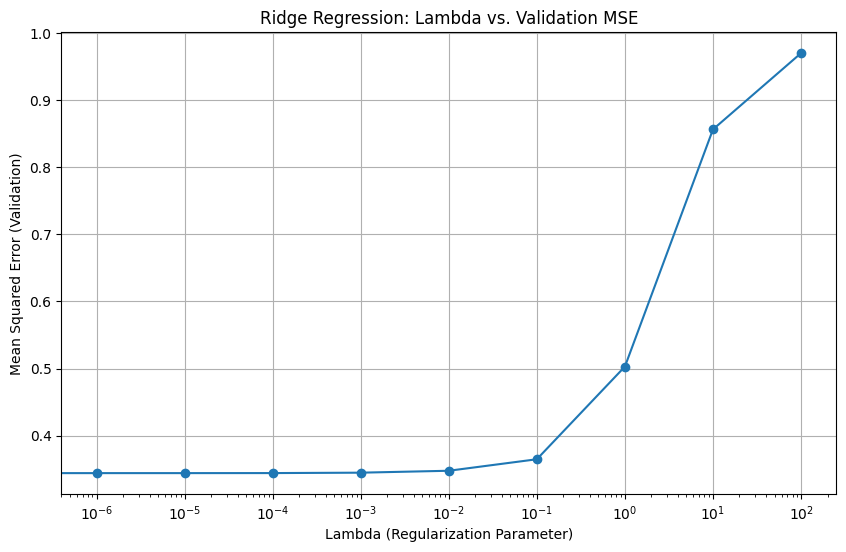

In [128]:
lambdas = [lam for lam, _ in results1]
mses = [mse for _, mse in results1]
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mses, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (Validation)')
plt.title('Ridge Regression: Lambda vs. Validation MSE')
plt.grid(True)
plt.show()

Calculate weights using Linear Regression - Gradient Descent

In [129]:
w_gd = np.zeros((X_with_bias.shape[1],1))
learning_rate = 0.01
iterations = 1000
tolerance = 1e-6
prev_mse = float('inf')

for i in range(10000):
    y_pred_training_GD = np.dot(X_with_bias, w_gd)
    errors =  y_pred_training_GD - x_target
    gradients = (1/N) * np.dot(X_with_bias.T, errors)
    w_gd -= learning_rate * gradients

    current_mse = mean_squared(x_target, y_pred_training_GD)
    if abs(prev_mse - current_mse) < tolerance:
        print(f"Converged after {i} iterations.")
        break
    prev_mse = current_mse

print("Weights from Gradient Descent:\n", w_gd)
mse_lin_manual_gd_validation = current_mse

y_pred_validation_GD = np.dot(v_with_bias, w_gd)
mae_lin_manual_gd_validation = mean_absolute(v_target, y_pred_validation_GD)
print("Final MSE from Gradient Descent:", mse_lin_manual_gd_validation)
print("Final MAE from Gradient Descent:", mae_lin_manual_gd_validation)

Converged after 3522 iterations.
Weights from Gradient Descent:
 [[ 2.47425793e-15]
 [ 6.28431402e-01]
 [ 1.02438756e-01]
 [-5.52913365e-02]
 [ 2.98178312e-01]
 [-4.36678948e-01]
 [ 2.26962963e-01]
 [-1.77953033e-01]
 [-3.45840945e-01]
 [-1.92353422e-01]
 [-2.56829344e-01]
 [ 7.98909681e-03]
 [-9.58971629e-03]
 [-3.90455056e-02]]
Final MSE from Gradient Descent: 0.35421872971283636
Final MAE from Gradient Descent: 0.43764464242169904


Calculate weights using Linear Regression - Ridge Regularization and Gradient Descent

In [130]:
# Ridge Regression using Gradient Descent (Manual Implementation)

N = X_with_bias.shape[0]   # number of training samples
d = X_with_bias.shape[1]   # number of features (including bias)

learning_rate = 0.01
iterations = 10000
tolerance = 1e-6

lambdas = [0, 0.001, 0.01, 0.1, 1, 10]
results = []
best_w = None

for lam in lambdas:
    w = np.zeros((d, 1))
    prev_mse = float('inf')

    for i in range(iterations):
        # Forward pass
        y_pred = np.dot(X_with_bias, w)
        errors = y_pred - x_target

        # Compute ridge gradient: (1/N) * [Xᵀ(Xw - y) + λw]
        gradients = (1/N) * (np.dot(X_with_bias.T, errors) + lam * w)

        # Update weights
        w -= learning_rate * gradients

        # Compute current training MSE
        current_mse = mean_squared(x_target, y_pred)

        # Stop early if improvement is very small
        if abs(prev_mse - current_mse) < tolerance:
            break
        prev_mse = current_mse

    # Evaluate model on validation data
    y_val_pred = np.dot(v_with_bias, w)
    mae = mean_absolute(v_target, y_val_pred)

    results.append((lam, current_mse, mae, w))
    print(f"Lambda = {lam:<6} | MSE = {current_mse:.6f} | MAE = {mae:.6f}")

# Select the lambda with the lowest validation MSE
best_lambda, best_mse, best_mae, w_ridge_gd = min(results, key=lambda x: x[1])

print("\nBest Lambda:", best_lambda)
print("Lowest Validation MSE:", best_mse)
print("Corresponding MAE:", best_mae)
print("Best Weights:\n", w_ridge_gd)

# Store results for later comparison
mse_ridge_gd_validation = best_mse
mae_ridge_gd_validation = best_mae


Lambda = 0      | MSE = 0.354219 | MAE = 0.437645
Lambda = 0.001  | MSE = 0.354219 | MAE = 0.437645
Lambda = 0.01   | MSE = 0.354219 | MAE = 0.437645
Lambda = 0.1    | MSE = 0.354219 | MAE = 0.437645
Lambda = 1      | MSE = 0.354225 | MAE = 0.437652
Lambda = 10     | MSE = 0.354287 | MAE = 0.437719

Best Lambda: 0
Lowest Validation MSE: 0.35421872971283636
Corresponding MAE: 0.43764464242169904
Best Weights:
 [[ 2.47425793e-15]
 [ 6.28431402e-01]
 [ 1.02438756e-01]
 [-5.52913365e-02]
 [ 2.98178312e-01]
 [-4.36678948e-01]
 [ 2.26962963e-01]
 [-1.77953033e-01]
 [-3.45840945e-01]
 [-1.92353422e-01]
 [-2.56829344e-01]
 [ 7.98909681e-03]
 [-9.58971629e-03]
 [-3.90455056e-02]]


# Scikit-Learn Implementation

Calculate weights using Linear Regression

In [131]:
lin_model = LinearRegression(fit_intercept=False)
lin_model.fit(X_with_bias, x_target)
y_pred_lin = lin_model.predict(v_with_bias)

mse_lin_scikit_validation = mean_squared_error(v_target, y_pred_lin)
mae_lin_scikit_validation = mean_absolute_error(v_target, y_pred_lin)

print("Linear Regression:")
print(f"  MSE = {mse_lin_scikit_validation}")
print(f"  MAE = {mae_lin_scikit_validation}")
print("-" * 40)

Linear Regression:
  MSE = 0.34420282562559146
  MAE = 0.43155528201271637
----------------------------------------


Calculate weights using Linear Regression - Lasso regulization

In [132]:
lasso_model = Lasso(alpha=0.001, fit_intercept=False)
lasso_model.fit(X_with_bias, x_target)
y_pred_lasso = lasso_model.predict(v_with_bias)

mse_lasso_validation = mean_squared_error(v_target, y_pred_lasso)
mae_lasso_validation = mean_absolute_error(v_target, y_pred_lasso)

print("Lasso Regression:")
print(f"  MSE = {mse_lasso_validation}")
print(f"  MAE = {mae_lasso_validation}")
print("-" * 40)

Lasso Regression:
  MSE = 0.34659985566362517
  MAE = 0.4344145290411946
----------------------------------------


Calculate weights using Linear Regression - Ridge regulization

In [133]:
ridge_model = Ridge(alpha=1.0, fit_intercept=False)
ridge_model.fit(X_with_bias, x_target)
y_pred_ridge = ridge_model.predict(v_with_bias)

mse_ridge_scikit_validation = mean_squared_error(v_target, y_pred_ridge)
mae_ridge_scikit_validation = mean_absolute_error(v_target, y_pred_ridge)

print("Ridge Regression:")
print(f"  MSE = {mse_ridge_scikit_validation}")
print(f"  MAE = {mae_ridge_scikit_validation}")
print("-" * 40)

Ridge Regression:
  MSE = 0.3442451830623264
  MAE = 0.4316257697810194
----------------------------------------


# Final Results Comparison (validtion dataset)

In [134]:
print("******Linear Regression******")
print("manual mse:", mse_lin_manual_validation)
print("manual mae:", mae_lin_manual_validation)
print("scikit mse:", mse_lin_scikit_validation)
print("scikit mae:", mae_lin_scikit_validation)
print("-" * 40)
print()

print("******Linear Regression (Gradient Descent)******")
print("manual mse (gd):", mse_lin_manual_gd_validation)
print("manual mae (gd):", mae_lin_manual_gd_validation)
print("-" * 40)
print()

print("******Ridge Regression******")
print("manual mse:", mse_ridge_validation)
print("manual mae:", mae_ridge_validation)
print("manual with gradient descent mse:", mse_ridge_gd_validation)
print("manual with gradient descent mae:", mae_ridge_gd_validation)
print("scikit mse:", mse_ridge_scikit_validation)
print("scikit mae:", mae_ridge_scikit_validation)
print("-" * 40)
print()

print("******Lasso Regression******")
print("scikit mse:", mse_lasso_validation)
print("scikit mae:", mae_lasso_validation)

******Linear Regression******
manual mse: 0.3442028256255914
manual mae: 0.4315552820127164
scikit mse: 0.34420282562559146
scikit mae: 0.43155528201271637
----------------------------------------

******Linear Regression (Gradient Descent)******
manual mse (gd): 0.35421872971283636
manual mae (gd): 0.43764464242169904
----------------------------------------

******Ridge Regression******
manual mse: 0.3442028256255914
manual mae: 0.4315552820127164
manual with gradient descent mse: 0.35421872971283636
manual with gradient descent mae: 0.43764464242169904
scikit mse: 0.3442451830623264
scikit mae: 0.4316257697810194
----------------------------------------

******Lasso Regression******
scikit mse: 0.34659985566362517
scikit mae: 0.4344145290411946


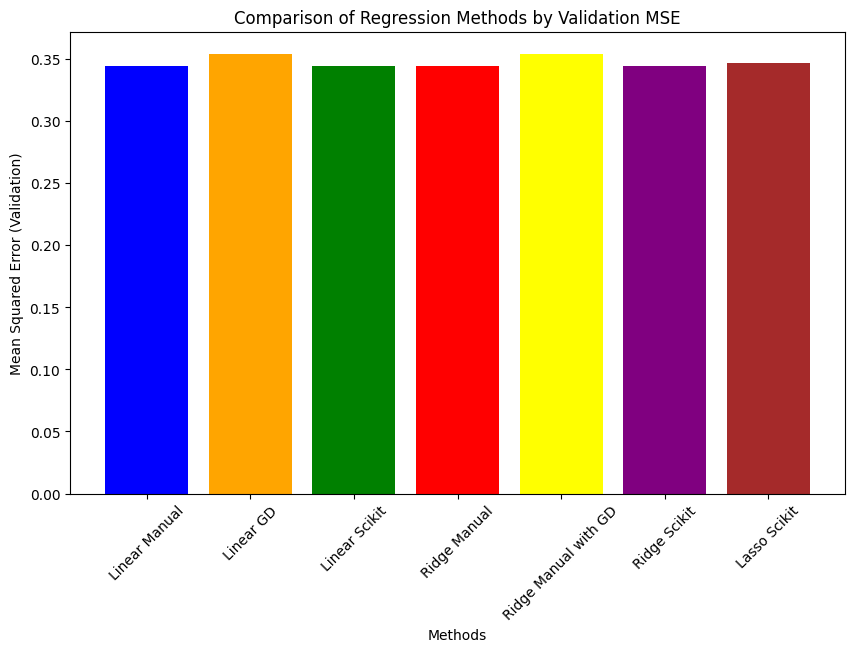

In [135]:
# --- Visualization: Comparing Model Performance on Validation Set ---

# Create a list of strings to serve as labels for the x-axis on our bar chart.
# Each string is the name of a regression model we have trained and evaluated.
methods = ['Linear Manual', 'Linear GD', 'Linear Scikit', 'Ridge Manual','Ridge Manual with GD','Ridge Scikit', 'Lasso Scikit']

# Create a list of the Mean Squared Error (MSE) values. 
# The order of these values must correspond exactly to the order of the model names in the 'methods' list.
mses = [mse_lin_manual_validation, mse_lin_manual_gd_validation, mse_lin_scikit_validation, mse_ridge_validation, mse_ridge_gd_validation, mse_ridge_scikit_validation, mse_lasso_validation]

# Create a new figure for plotting, specifying its size in inches (width, height) for better readability.
plt.figure(figsize=(10, 6))

# Generate the bar chart. 'methods' provides the categories, and 'mses' provides the height of each bar.
# A unique color is assigned to each bar for clear visual distinction.
plt.bar(methods, mses, color=['blue', 'orange', 'green', 'red', 'yellow','purple', 'brown'])

# Set the label for the x-axis to describe what the bars represent.
plt.xlabel('Methods')

# Set the label for the y-axis to describe the evaluation metric being used.
plt.ylabel('Mean Squared Error (Validation)')

# Set the main title for the entire plot to summarize its purpose.
plt.title('Comparison of Regression Methods by Validation MSE')

# Rotate the labels on the x-axis (the method names) by 45 degrees.
# This prevents the text from overlapping, which can happen with long labels.
plt.xticks(rotation=45)

# Display the final, generated plot.
plt.show()

# applying trained models on test dataset & calculating error

In [136]:
# ===================================================================
# FINAL EVALUATION ON THE TEST SET
# ===================================================================
# This script applies all the previously trained models to the unseen 
# test data (Test_with_bias, t_target) to evaluate their final performance.

print("******Linear Regression******")

# --- Manual Linear Regression (Normal Equation) ---
# Use the weights (W_lin) calculated via the normal equation to make predictions on the test set.
prediction_lin = np.dot(Test_with_bias, W_lin)
# Calculate the Mean Squared Error and Mean Absolute Error for the manual model.
mse_lin_manual_test = mean_squared(t_target, prediction_lin)
mae_lin_manual_test = mean_absolute(t_target, prediction_lin)
print(f"Manual Linear Regression on Test Set  |  Test MSE = {mse_lin_manual_test}  |  Test MAE = {mae_lin_manual_test}")

# --- Scikit-learn Linear Regression ---
# Use the trained scikit-learn model (lin_model) to make predictions on the test set.
prediction_lin_scikit = lin_model.predict(Test_with_bias)
# Calculate the MSE and MAE for the scikit-learn model.
mse_lin_scikit_test = mean_squared_error(t_target, prediction_lin_scikit)
mae_lin_scikit_test = mean_absolute_error(t_target, prediction_lin_scikit)
print(f"Scikit-learn Linear Regression on Test Set  |  Test MSE = {mse_lin_scikit_test}  |  Test MAE = {mae_lin_scikit_test}")
print()

print("******Linear Regression (Gradient Descent)******")

# --- Manual Linear Regression (Gradient Descent) ---
# Use the weights (w_gd) found via gradient descent to make predictions on the test set.
prediction_gd = np.dot(Test_with_bias, w_gd)
# Calculate the final MSE and MAE for the gradient descent model.
mse_gd_test = mean_squared(t_target, prediction_gd)
mae_gd_test = mean_absolute(t_target, prediction_gd)
print(f"Manual Linear Regression (GD) on Test Set  |  Test MSE = {mse_gd_test}  |  Test MAE = {mae_gd_test}")
print()

print("******Ridge Regression******")

# --- Manual Ridge Regression (Normal Equation) ---
# Use the optimal Ridge weights (W_ridge) to predict on the test set.
prediction_ridge = np.dot(Test_with_bias , W_ridge)
# Calculate the MSE and MAE for the manual Ridge model.
mse_ridge_test = mean_squared(t_target, prediction_ridge)
mae_ridge_test = mean_absolute(t_target, prediction_ridge)
print(f"Manual Ridge Regression on Test Set  |  Test MSE = {mse_ridge_test}  |  Test MAE = {mae_ridge_test}")

# --- Manual Ridge Regression (Gradient Descent) ---
# Use the optimal Ridge weights found via gradient descent (w_ridge_gd) for predictions.
prediction_ridge_gd = np.dot(Test_with_bias, w_ridge_gd)
# Calculate the MSE and MAE for this model.
mse_ridge_gd_test = mean_squared(t_target, prediction_ridge_gd)
mae_ridge_gd_test = mean_absolute(t_target, prediction_ridge_gd)
print(f"Manual Ridge Regression (GD) on Test Set  |  Test MSE = {mse_ridge_gd_test}  |  Test MAE = {mae_ridge_gd_test}")

# --- Scikit-learn Ridge Regression ---
# Use the trained scikit-learn Ridge model for predictions on the test set.
prediction_ridge_scikit = ridge_model.predict(Test_with_bias)
# Calculate the final MSE and MAE.
mse_ridge_scikit_test = mean_squared_error(t_target, prediction_ridge_scikit)
mae_ridge_scikit_test = mean_absolute_error(t_target, prediction_ridge_scikit)
print(f"Scikit-learn Ridge Regression on Test Set  |  Test MSE = {mse_ridge_scikit_test}  |  Test MAE = {mae_ridge_scikit_test}")
print()

print("******Lasso Regression******")

# --- Scikit-learn Lasso Regression ---
# Use the trained scikit-learn Lasso model to make predictions on the test set.
prediction_lasso = lasso_model.predict(Test_with_bias)
# Calculate the final MSE and MAE for the Lasso model.
mse_lasso_test = mean_squared_error(t_target, prediction_lasso)
mae_lasso_test = mean_absolute_error(t_target, prediction_lasso)
print(f"Scikit-learn Lasso Regression on Test Set  |  Test MSE = {mse_lasso_test}  |  Test MAE = {mae_lasso_test}")

******Linear Regression******
Manual Linear Regression on Test Set  |  Test MSE = 0.3850569240053229  |  Test MAE = 0.44211861983157097
Scikit-learn Linear Regression on Test Set  |  Test MSE = 0.3850569240053223  |  Test MAE = 0.44211861983157025

******Linear Regression (Gradient Descent)******
Manual Linear Regression (GD) on Test Set  |  Test MSE = 0.3873857037303584  |  Test MAE = 0.4450897761613654

******Ridge Regression******
Manual Ridge Regression on Test Set  |  Test MSE = 0.3850569240053229  |  Test MAE = 0.44211861983157097
Manual Ridge Regression (GD) on Test Set  |  Test MSE = 0.3873857037303584  |  Test MAE = 0.4450897761613654
Scikit-learn Ridge Regression on Test Set  |  Test MSE = 0.384995823468506  |  Test MAE = 0.4420889253703323

******Lasso Regression******
Scikit-learn Lasso Regression on Test Set  |  Test MSE = 0.3853440473001551  |  Test MAE = 0.4433699646298227


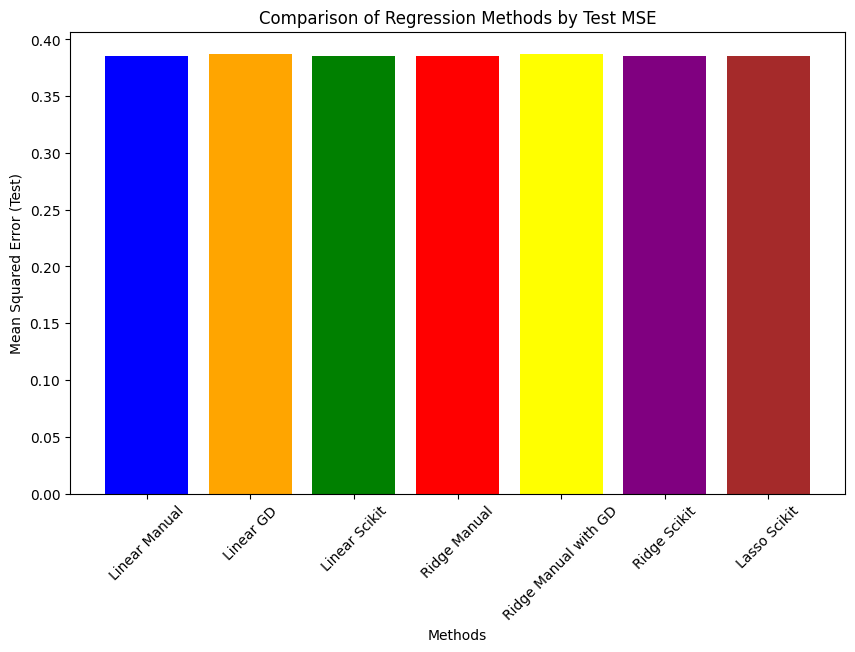

In [137]:
# graph for all methods on test set
methods = ['Linear Manual', 'Linear GD', 'Linear Scikit', 'Ridge Manual','Ridge Manual with GD','Ridge Scikit', 'Lasso Scikit']
mses = [mse_lin_manual_test, mse_gd_test, mse_lin_scikit_test, mse_ridge_test, mse_ridge_gd_test, mse_ridge_scikit_test, mse_lasso_test]
plt.figure(figsize=(10, 6))
plt.bar(methods, mses, color=['blue', 'orange', 'green', 'red', 'yellow','purple', 'brown'])
plt.xlabel('Methods')
plt.ylabel('Mean Squared Error (Test)')
plt.title('Comparison of Regression Methods by Test MSE')
plt.xticks(rotation=45)
plt.show()

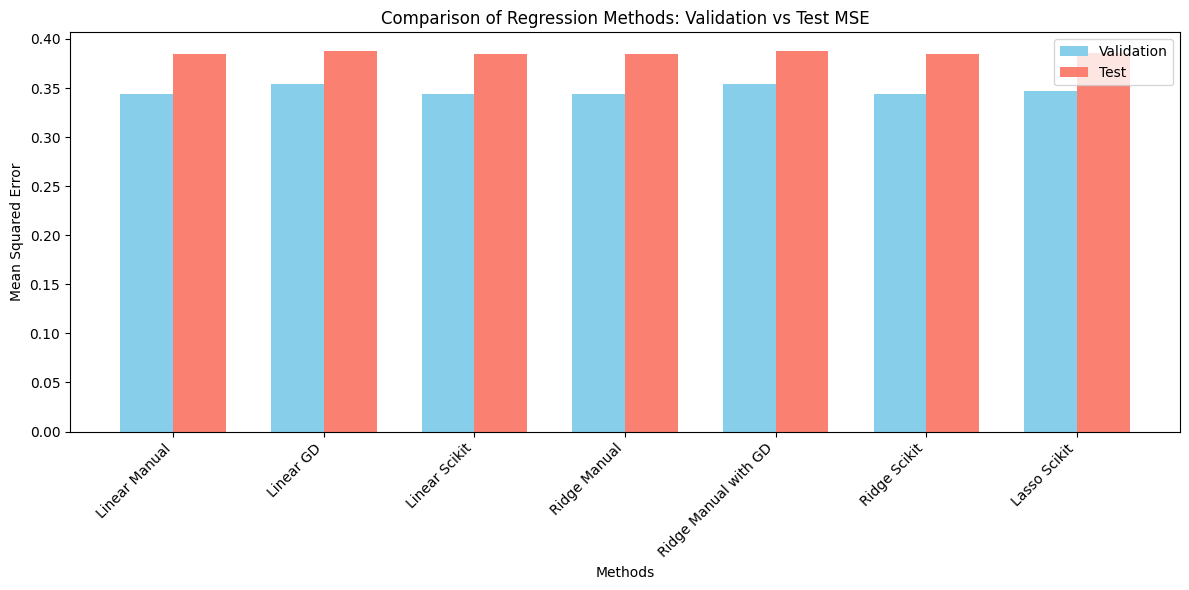

In [138]:
methods = [
    'Linear Manual',
    'Linear GD',
    'Linear Scikit',
    'Ridge Manual',
    'Ridge Manual with GD',
    'Ridge Scikit',
    'Lasso Scikit'
]

mse_test = [
    mse_lin_manual_test,
    mse_gd_test,
    mse_lin_scikit_test,
    mse_ridge_test,
    mse_ridge_gd_test,
    mse_ridge_scikit_test,
    mse_lasso_test
]

mse_validation = [
    mse_lin_manual_validation,
    mse_lin_manual_gd_validation,
    mse_lin_scikit_validation,
    mse_ridge_validation,
    mse_ridge_gd_validation,
    mse_ridge_scikit_validation,
    mse_lasso_validation
]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, mse_validation, width, label='Validation', color='skyblue')
plt.bar(x + width/2, mse_test, width, label='Test', color='salmon')

plt.xlabel('Methods')
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Regression Methods: Validation vs Test MSE')
plt.xticks(x, methods, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
